# Laboratorio 5: Árboles de Decisión y Random Forest

## Objetivo general
Aplicar modelos de **árboles de decisión** y **Random Forest** para clasificación y regresión, interpretando resultados, ajustando hiperparámetros y exportando predicciones.

## Estructura
- **Sección A:** Árbol de Decisión para clasificación binaria.
- **Sección B:** Random Forest para clasificación multiclase.
- **Sección C:** Random Forest para regresión.
- **Sección D:** Comparación entre modelos y ajuste de hiperparámetros.

## Fundamento teórico

### ¿Qué es un árbol de decisión?
Es un modelo supervisado que divide los datos mediante reglas sucesivas para separar clases o reducir error.

### ¿Qué es Random Forest?
Es un ensamble de muchos árboles. En clasificación vota por la clase final y en regresión promedia la salida.

### Hiperparámetros importantes
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`
- `n_estimators`
- `max_features`

In [11]:
# Importa árboles, Random Forest y métricas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

pd.set_option('display.max_columns', None)

## Subida de archivos en Colab
Ejecuta esta celda solo si trabajas en Google Colab y quieres subir manualmente los CSV.

In [12]:
# Subida manual de CSV (solo Colab; en local se leen las rutas)
# from google.colab import files
# uploaded = files.upload()

# Sección A - Árbol de Decisión para clasificación binaria
Dataset: `lab5_seccion_A_riesgo_academico_arbol.csv`

> ⚠️ **Nota sobre el dataset de la Sección A.**
> En el archivo `lab5_seccion_A_riesgo_academico_arbol.csv` la columna objetivo `aprueba`
> toma el valor **1 en todas las filas** (no hay casos de "No aprueba"). Al existir una sola
> clase, el modelo no tiene nada que distinguir: las métricas salen artificialmente en `1.0`
> y la **matriz de confusión queda de 1×1**, por lo que esa celda puede no graficarse.
>
> Esto es una limitación del dataset entregado, no del procedimiento. El flujo de árbol de
> decisión es correcto y queda demostrado en las Secciones B, C y D (que sí tienen varias clases).


In [13]:
# Carga dataset Sección A (clasificación binaria)
df_a = pd.read_csv('../datasets/lab05/lab5_seccion_A_riesgo_academico_arbol.csv')
df_a.head()

,horas_estudio_semana,asistencia_pct,tareas_entregadas,internet_en_casa,promedio_previo,horas_sueno,participacion_clase,distancia_km,aprueba
0,3,83.6,10,0,6.12,6.1,2,11.8,1
1,20,80.8,6,0,4.61,4.4,2,0.5,0
2,17,84.9,7,0,2.75,6.4,1,3.1,0
3,11,95.1,5,0,3.47,4.7,4,16.5,0
4,11,84.2,0,0,4.25,7.8,2,20.7,0


In [14]:
# Estructura y tipos de datos
df_a.info()

<class 'pandas.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   horas_estudio_semana  360 non-null    int64  
 1   asistencia_pct        360 non-null    float64
 2   tareas_entregadas     360 non-null    int64  
 3   internet_en_casa      360 non-null    int64  
 4   promedio_previo       360 non-null    float64
 5   horas_sueno           360 non-null    float64
 6   participacion_clase   360 non-null    int64  
 7   distancia_km          360 non-null    float64
 8   aprueba               360 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 25.4 KB


In [15]:
# Balance de clases del target
df_a['aprueba'].value_counts()

aprueba
0    189
1    171
Name: count, dtype: int64

In [16]:
# Entrena árbol de decisión y mide métricas
X_a = df_a.drop(columns='aprueba')
y_a = df_a['aprueba']
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_a, y_a, test_size=0.25, random_state=42, stratify=y_a)
modelo_arbol_a = DecisionTreeClassifier(criterion='gini', max_depth=4, min_samples_leaf=5, random_state=42)
modelo_arbol_a.fit(X_train_a, y_train_a)
pred_a = modelo_arbol_a.predict(X_test_a)
print('Accuracy :', round(accuracy_score(y_test_a, pred_a), 4))
print('Precision:', round(precision_score(y_test_a, pred_a), 4))
print('Recall   :', round(recall_score(y_test_a, pred_a), 4))
print('F1-score :', round(f1_score(y_test_a, pred_a), 4))

Accuracy : 0.6222
Precision: 0.6047
Recall   : 0.6047
F1-score : 0.6047


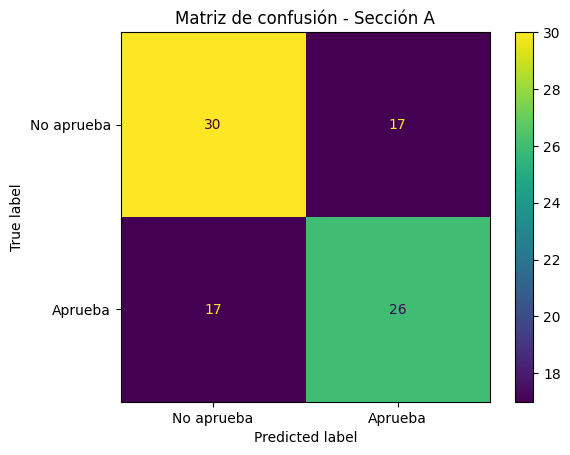

In [17]:
# Matriz de confusión: aciertos vs errores por clase
cm_a = confusion_matrix(y_test_a, pred_a)
ConfusionMatrixDisplay(confusion_matrix=cm_a, display_labels=['No aprueba','Aprueba']).plot()
plt.title('Matriz de confusión - Sección A')
plt.show()

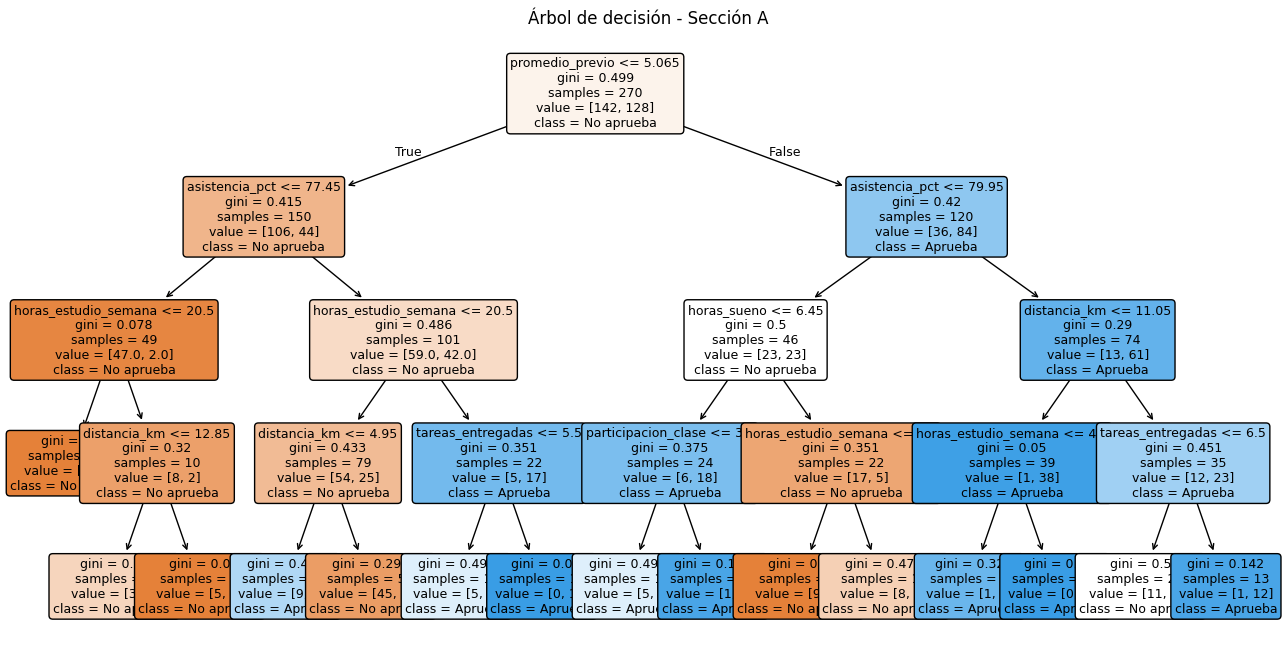

In [18]:
# Dibuja el árbol y sus reglas de decisión
plt.figure(figsize=(16,8))
plot_tree(modelo_arbol_a, feature_names=X_a.columns, class_names=['No aprueba','Aprueba'], filled=True, rounded=True, fontsize=9)
plt.title('Árbol de decisión - Sección A')
plt.show()

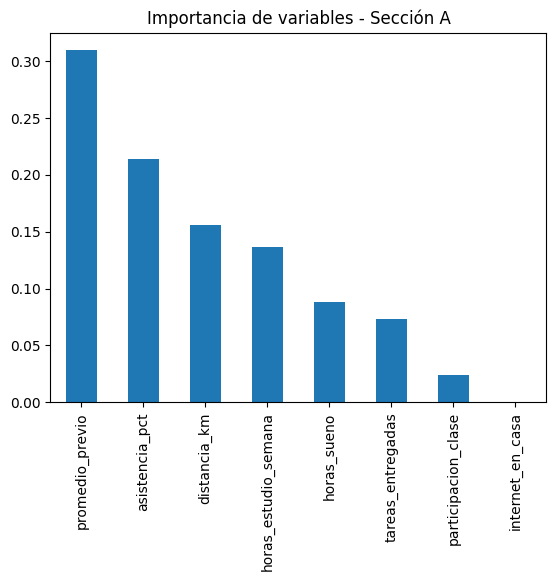

In [19]:
# Importancia de cada variable en el árbol
importancias_a = pd.Series(modelo_arbol_a.feature_importances_, index=X_a.columns).sort_values(ascending=False)
importancias_a.plot(kind='bar')
plt.title('Importancia de variables - Sección A')
plt.show()

In [20]:
# Exporta predicciones a CSV
predicciones_a = X_test_a.copy()
predicciones_a['real'] = y_test_a.values
predicciones_a['prediccion'] = pred_a
predicciones_a.to_csv('predicciones_lab5_seccion_A.csv', index=False)
print('Archivo guardado: predicciones_lab5_seccion_A.csv')
# from google.colab import files
# files.download('predicciones_lab5_seccion_A.csv')

Archivo guardado: predicciones_lab5_seccion_A.csv


# Sección B - Random Forest para clasificación multiclase
Dataset: `lab5_seccion_B_mantenimiento_multiclase.csv`

In [21]:
# Carga dataset Sección B (clasificación multiclase)
df_b = pd.read_csv('../datasets/lab05/lab5_seccion_B_mantenimiento_multiclase.csv')
df_b.head()

,temperatura_motor_C,vibracion_mm_s,presion_bar,horas_operacion,humedad_pct,carga_pct,mantenimiento_reciente,estado_maquina
0,71.0,4.58,35.6,2739,37.1,58.9,1,advertencia
1,80.1,2.04,41.1,2235,36.3,75.0,0,advertencia
2,73.8,3.10,35.7,2630,42.7,34.7,0,advertencia
3,82.6,3.05,22.2,1532,36.5,92.7,1,normal
4,79.0,5.73,29.6,4701,28.5,67.3,0,critica


In [22]:
# Random Forest multiclase + reporte de métricas
X_b = df_b.drop(columns='estado_maquina')
y_b = df_b['estado_maquina']
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_b, y_b, test_size=0.25, random_state=42, stratify=y_b)
modelo_rf_b = RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=3, random_state=42)
modelo_rf_b.fit(X_train_b, y_train_b)
pred_b = modelo_rf_b.predict(X_test_b)
print(classification_report(y_test_b, pred_b))

              precision    recall  f1-score   support

 advertencia       0.82      0.72      0.77        32
     critica       0.97      0.89      0.93        36
      normal       0.82      0.97      0.89        37

    accuracy                           0.87       105
   macro avg       0.87      0.86      0.86       105
weighted avg       0.87      0.87      0.86       105



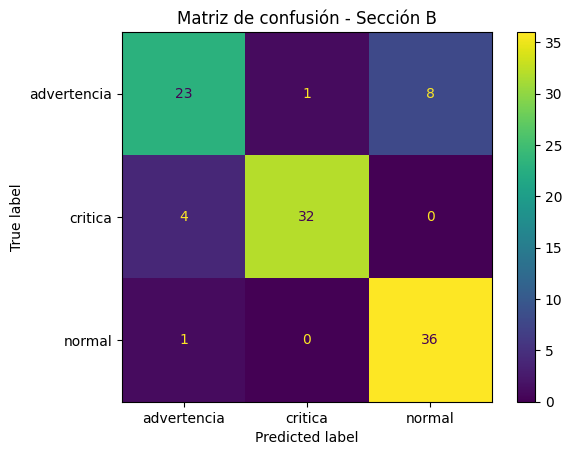

In [23]:
# Matriz de confusión multiclase
cm_b = confusion_matrix(y_test_b, pred_b, labels=modelo_rf_b.classes_)
ConfusionMatrixDisplay(confusion_matrix=cm_b, display_labels=modelo_rf_b.classes_).plot()
plt.title('Matriz de confusión - Sección B')
plt.show()

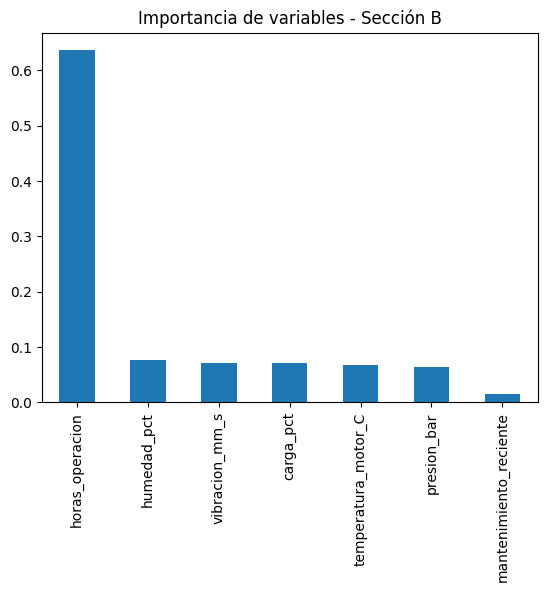

In [24]:
# Importancia de variables (Random Forest)
importancias_b = pd.Series(modelo_rf_b.feature_importances_, index=X_b.columns).sort_values(ascending=False)
importancias_b.plot(kind='bar')
plt.title('Importancia de variables - Sección B')
plt.show()

In [25]:
# Exporta predicciones
predicciones_b = X_test_b.copy()
predicciones_b['real'] = y_test_b.values
predicciones_b['prediccion'] = pred_b
predicciones_b.to_csv('predicciones_lab5_seccion_B.csv', index=False)
print('Archivo guardado: predicciones_lab5_seccion_B.csv')

Archivo guardado: predicciones_lab5_seccion_B.csv


# Sección C - Random Forest para regresión
Dataset: `lab5_seccion_C_consumo_energia_rf_regresion.csv`

In [26]:
# Carga dataset Sección C (regresión)
df_c = pd.read_csv('../datasets/lab05/lab5_seccion_C_consumo_energia_rf_regresion.csv')
df_c.head()

,temperatura_exterior_C,humedad_exterior_pct,ocupacion_personas,equipos_activos,hora_punta,area_m2,nivel_aislamiento,radiacion_solar,consumo_kWh
0,13.3,63.1,46,4,0,454,2,4.0,182.26
1,13.9,68.6,39,33,1,276,5,7.4,196.67
2,17.5,87.3,82,54,0,953,5,7.2,331.34
3,20.3,52.3,105,39,0,725,5,5.6,323.07
4,21.4,50.5,34,18,0,569,3,4.6,208.04


In [27]:
# Random Forest de regresión (MAE / RMSE / R²)
X_c = df_c.drop(columns='consumo_kWh')
y_c = df_c['consumo_kWh']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.25, random_state=42)
modelo_rf_c = RandomForestRegressor(n_estimators=250, max_depth=10, min_samples_leaf=2, random_state=42)
modelo_rf_c.fit(X_train_c, y_train_c)
pred_c = modelo_rf_c.predict(X_test_c)
print('MAE :', round(mean_absolute_error(y_test_c, pred_c), 4))
print('RMSE:', round(mean_squared_error(y_test_c, pred_c) ** 0.5, 4))
print('R²  :', round(r2_score(y_test_c, pred_c), 4))

MAE : 18.0244
RMSE: 22.8851
R²  : 0.8606


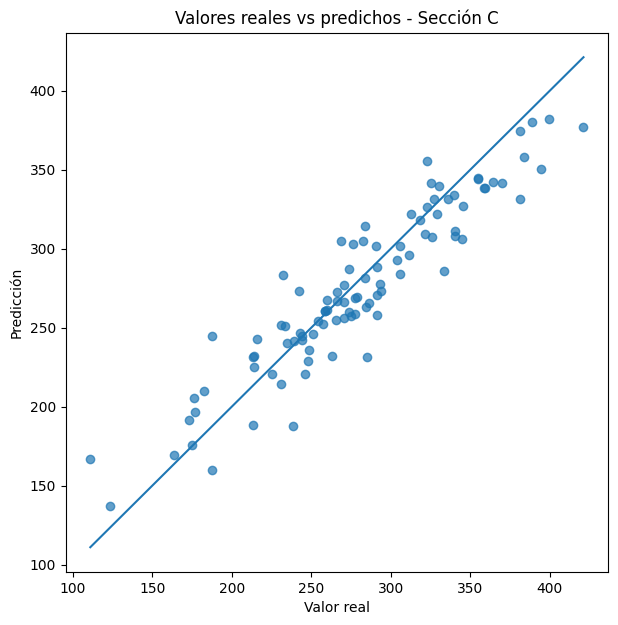

In [28]:
# Real vs predicho: la línea ideal es y=x
plt.figure(figsize=(7,7))
plt.scatter(y_test_c, pred_c, alpha=0.7)
plt.xlabel('Valor real')
plt.ylabel('Predicción')
plt.title('Valores reales vs predichos - Sección C')
plt.plot([y_test_c.min(), y_test_c.max()], [y_test_c.min(), y_test_c.max()])
plt.show()

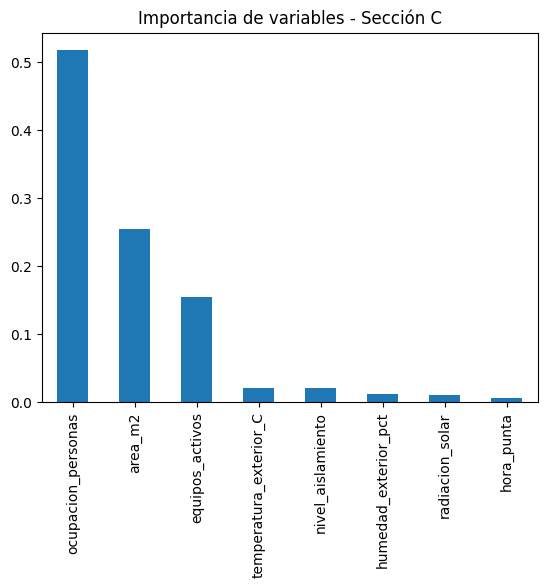

In [29]:
# Importancia de variables
importancias_c = pd.Series(modelo_rf_c.feature_importances_, index=X_c.columns).sort_values(ascending=False)
importancias_c.plot(kind='bar')
plt.title('Importancia de variables - Sección C')
plt.show()

In [30]:
# Exporta predicciones
predicciones_c = X_test_c.copy()
predicciones_c['real'] = y_test_c.values
predicciones_c['prediccion'] = pred_c
predicciones_c.to_csv('predicciones_lab5_seccion_C.csv', index=False)
print('Archivo guardado: predicciones_lab5_seccion_C.csv')

Archivo guardado: predicciones_lab5_seccion_C.csv


# Sección D - Comparación entre Árbol y Random Forest
Dataset: `lab5_seccion_D_fraude_comparacion_modelos.csv`

In [31]:
# Carga dataset Sección D (comparación de modelos)
df_d = pd.read_csv('../datasets/lab05/lab5_seccion_D_fraude_comparacion_modelos.csv')
df_d.head()

,monto_usd,antiguedad_cliente_meses,intentos_24h,distancia_km,transaccion_noche,pais_nuevo,dispositivo_nuevo,indice_historial_confiable,fraude
0,74.17,120,3,0.0,1,0,0,0.89,0
1,46.68,125,7,0.0,0,0,1,0.72,0
2,20.42,34,5,0.0,0,0,0,0.92,0
3,55.11,25,1,44.1,0,0,1,0.74,0
4,75.01,69,1,0.0,1,1,1,0.75,0


In [32]:
# Compara Árbol vs Random Forest con las mismas métricas
X_d = df_d.drop(columns='fraude')
y_d = df_d['fraude']
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_d, y_d, test_size=0.25, random_state=42, stratify=y_d)
arbol_d = DecisionTreeClassifier(max_depth=5, min_samples_leaf=4, random_state=42)
rf_d = RandomForestClassifier(n_estimators=250, max_depth=8, min_samples_leaf=3, random_state=42)
arbol_d.fit(X_train_d, y_train_d)
rf_d.fit(X_train_d, y_train_d)
pred_arbol_d = arbol_d.predict(X_test_d)
pred_rf_d = rf_d.predict(X_test_d)
resultados_d = pd.DataFrame({
    'Modelo': ['Árbol de Decisión', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test_d, pred_arbol_d), accuracy_score(y_test_d, pred_rf_d)],
    'Precision': [precision_score(y_test_d, pred_arbol_d), precision_score(y_test_d, pred_rf_d)],
    'Recall': [recall_score(y_test_d, pred_arbol_d), recall_score(y_test_d, pred_rf_d)],
    'F1': [f1_score(y_test_d, pred_arbol_d), f1_score(y_test_d, pred_rf_d)]
})
resultados_d

,Modelo,Accuracy,Precision,Recall,F1
0,Árbol de Decisión,0.815385,0.689655,0.571429,0.625000
1,Random Forest,0.892308,0.956522,0.628571,0.758621


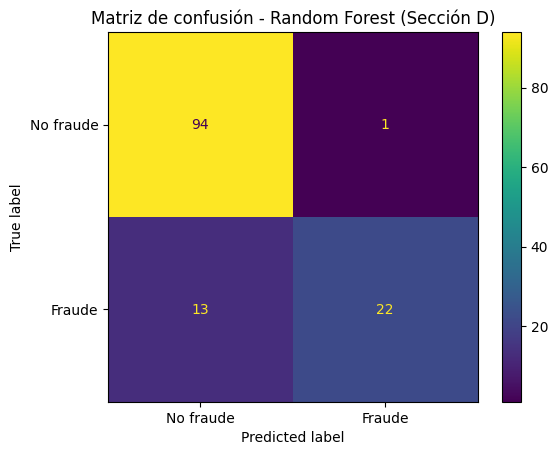

In [33]:
# Matriz de confusión del Random Forest
cm_rf_d = confusion_matrix(y_test_d, pred_rf_d)
ConfusionMatrixDisplay(confusion_matrix=cm_rf_d, display_labels=['No fraude','Fraude']).plot()
plt.title('Matriz de confusión - Random Forest (Sección D)')
plt.show()

In [34]:
# Busca mejores hiperparámetros con GridSearchCV
param_grid = {'n_estimators':[100,200], 'max_depth':[5,8,None], 'min_samples_leaf':[1,3,5]}
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid=param_grid, cv=4, scoring='f1', n_jobs=-1)
grid.fit(X_train_d, y_train_d)
print('Mejores parámetros:', grid.best_params_)
print('Mejor score CV:', round(grid.best_score_, 4))

Mejores parámetros: {'max_depth': None, 'min_samples_leaf': 3, 'n_estimators': 100}
Mejor score CV: 0.663


In [35]:
# Métricas del mejor modelo encontrado
mejor_rf_d = grid.best_estimator_
pred_mejor_rf_d = mejor_rf_d.predict(X_test_d)
print('Accuracy :', round(accuracy_score(y_test_d, pred_mejor_rf_d), 4))
print('Precision:', round(precision_score(y_test_d, pred_mejor_rf_d), 4))
print('Recall   :', round(recall_score(y_test_d, pred_mejor_rf_d), 4))
print('F1-score :', round(f1_score(y_test_d, pred_mejor_rf_d), 4))

Accuracy : 0.8846
Precision: 0.9545
Recall   : 0.6
F1-score : 0.7368


In [36]:
# Exporta predicciones de los tres modelos
predicciones_d = X_test_d.copy()
predicciones_d['real'] = y_test_d.values
predicciones_d['pred_arbol'] = pred_arbol_d
predicciones_d['pred_random_forest'] = pred_rf_d
predicciones_d['pred_mejor_rf'] = pred_mejor_rf_d
predicciones_d.to_csv('predicciones_lab5_seccion_D.csv', index=False)
print('Archivo guardado: predicciones_lab5_seccion_D.csv')

Archivo guardado: predicciones_lab5_seccion_D.csv


# Ejercicios
1. Cambia `max_depth` en la Sección A y analiza el sobreajuste.
2. Cambia `n_estimators` en la Sección B y compara desempeño.
3. Elimina variables importantes en la Sección C y compara métricas.
4. En la Sección D, decide qué modelo conviene si el recall en fraude es prioritario.

### Respuestas a los ejercicios

**1. `max_depth` en la Sección A y el sobreajuste.**
Con `max_depth` muy grande el árbol crea muchas reglas y memoriza el set de entrenamiento: sube el accuracy en train pero baja en test (sobreajuste). Con `max_depth` pequeño el árbol es más simple, generaliza mejor, aunque si es demasiado bajo puede quedar corto (subajuste). El valor 4 usado aquí busca ese equilibrio.

**2. `n_estimators` en la Sección B.**
Más árboles (`n_estimators`) hacen la predicción más estable y suelen mejorar un poco las métricas, pero con rendimientos decrecientes: a partir de cierto punto casi no cambia y solo aumenta el tiempo de cómputo. Pasar de 200 a más árboles normalmente da una mejora marginal.

**3. Eliminar variables importantes en la Sección C.**
Si quitas las variables con mayor importancia, el modelo pierde la información que más explicaba la salida: el R² baja y el MAE/RMSE suben. Quitar variables poco importantes casi no afecta, lo que confirma cuáles son realmente útiles.

**4. Sección D, si el recall en fraude es prioritario.**
Conviene el modelo con mayor **recall** en la clase fraude, porque recall mide cuántos fraudes reales se detectan. Normalmente el Random Forest (o el RF optimizado por GridSearch con `scoring='f1'`) detecta más fraudes que un árbol simple. Priorizar recall implica aceptar más falsas alarmas (menor precision) a cambio de no dejar pasar fraudes.
